In [1]:
import pandas as pd

In [2]:
import torch
from torch import nn, optim

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

In [4]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [5]:
import random

In [6]:
import numpy as np

In [7]:
import matplotlib.pyplot as plot

In [33]:
from sklearn.model_selection import train_test_split

In [8]:
df = pd.read_csv("D:/git/dados/nlp/news_sentiment_analysis.csv", encoding="utf-8")

In [10]:
df = df[["Description", "Type"]]
df

,Description,Type
0,"ST. GEORGE — Kaitlyn Larson, a first-year teac...",Business
1,"Harare, Zimbabwe – Local businesses are grappl...",Business
2,(marketscreener.com) Billionaire Elon Musk has...,Business
3,(marketscreener.com) A U.S. trade regulator on...,Business
4,4.5 million households in the U.S. have solar ...,Business
...,...,...
3495,QRG Capital Management Inc. increased its stak...,Technology
3496,QRG Capital Management Inc. bought a new posit...,Technology
3497,QRG Capital Management Inc. boosted its stake ...,Technology
3498,"WESTFORD, Mass., July 18, 2024 /PRNewswire/ --...",Technology


In [12]:
df["Type"].unique()

array(['Business', 'Entertainment', 'General', 'Health', 'Science',
       'Sports', 'Technology'], dtype=object)

In [13]:
# mapping_type = {
#         'Business': [1, 0, 0, 0, 0, 0, 0], 
#         'Entertainment': [0, 1, 0, 0, 0, 0, 0], 
#         'General': [0, 0, 1, 0, 0, 0, 0], 
#         'Health': [0, 0, 0, 1, 0, 0, 0], 
#         'Science': [0, 0, 0, 0, 1, 0, 0], 
#         'Sports': [0, 0, 0, 0, 0, 1, 0], 
#         'Technology': [0, 0, 0, 0, 0, 0, 1]
# } 
# df["type_number"] = df["Type"].map( mapping_type )

In [14]:
encoder = LabelEncoder()
oh_encoder = OneHotEncoder(sparse_output=False)

In [15]:
Y_label = encoder.fit_transform(df["Type"])
Y_label = Y_label.reshape(-1, 1)
Y_label

array([[0],
       [0],
       [0],
       ...,
       [6],
       [6],
       [6]], shape=(3500, 1))

In [16]:
Y = oh_encoder.fit_transform(Y_label)
oh_encoder.categories_

[array([0, 1, 2, 3, 4, 5, 6])]

In [ ]:
#         'Business': [1, 0, 0, 0, 0, 0, 0], 
#         'Entertainment': [0, 1, 0, 0, 0, 0, 0], 
#         'General': [0, 0, 1, 0, 0, 0, 0], 
#         'Health': [0, 0, 0, 1, 0, 0, 0], 
#         'Science': [0, 0, 0, 0, 1, 0, 0], 
#         'Sports': [0, 0, 0, 0, 0, 1, 0], 
#         'Technology': [0, 0, 0, 0, 0, 0, 1]

In [18]:
# Y = torch.tensor(df["type_number"], dtype=torch.float32)
# Y = torch.reshape( Y, (-1, 1) )
# Y.shape
Y = torch.tensor(Y, dtype=torch.float32)
Y

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        [1., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 0., 1.]])

In [19]:
MAX_PALAVRAS = 2000

In [20]:
vetorizador = CountVectorizer(max_features = MAX_PALAVRAS)

In [21]:
X = vetorizador.fit_transform( df["Description"] )
X = torch.tensor(X.toarray(), dtype=torch.float32)
X

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [44]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state = 75)

In [45]:
print(f"{Y_train[0]}  -  {X_train[0]}")

tensor([0., 0., 1., 0., 0., 0., 0.])  -  tensor([0., 0., 0.,  ..., 0., 0., 0.])


In [46]:
vocabulario = vetorizador.get_feature_names_out()
vocabulario

array(['00', '000', '01', ..., 'überkauft', 'überverkauft', 'überwiegend'],
      shape=(2000,), dtype=object)

In [47]:
modelo = nn.Linear(in_features = MAX_PALAVRAS, out_features = 7)
otimizador = optim.SGD( modelo.parameters(), lr=1)
criterio = nn.CrossEntropyLoss() # Cross Entropy Perda

In [48]:
lista_loss = []
for epoca in range(2000):
    y_hat = modelo( X_train ) 
    loss = criterio( y_hat, Y_train )
    lista_loss.append( loss )
    if epoca % 100 == 0:
        print(f"Loss: {loss}")
    otimizador.zero_grad()
    loss.backward()
    otimizador.step()

Loss: 1.9388409852981567
Loss: 0.2854521572589874
Loss: 0.19217941164970398
Loss: 0.152580127120018
Loss: 0.1299280822277069
Loss: 0.11520963162183762
Loss: 0.10482052713632584
Loss: 0.09705327451229095
Loss: 0.0910067930817604
Loss: 0.08615710586309433
Loss: 0.08217661827802658
Loss: 0.0788489356637001
Loss: 0.07602483779191971
Loss: 0.07359782606363297
Loss: 0.07148975878953934
Loss: 0.06964188069105148
Loss: 0.0680091455578804
Loss: 0.066556416451931
Loss: 0.06525582075119019
Loss: 0.0640849694609642


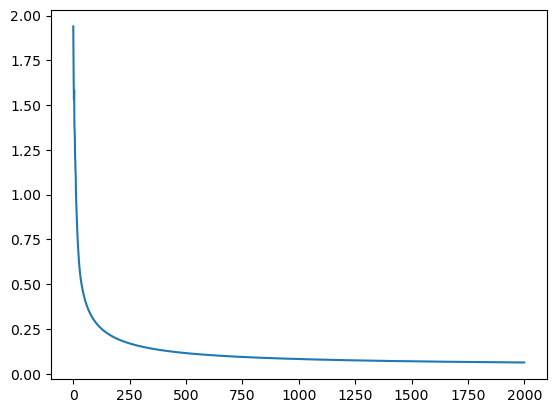

In [49]:
lista_tensor = torch.tensor( lista_loss ) 
plot.plot( lista_tensor )

In [52]:
Y_hat_test.shape

torch.Size([700, 7])

In [60]:
with torch.no_grad():
    Y_hat_test = modelo( X_test )
    indice_hat = np.argmax(Y_hat_test, axis=1)
    # print(indice_hat)
    indice_test = np.argmax(Y_test, axis=1)
    # print(indice_test)
    erros = indice_hat - indice_test
    # print(erros)
    erros_finais = erros[ erros != 0 ]
    total_elementos = len(Y_hat_test)
    acertos = total_elementos - len(erros_finais)
    acuracy = acertos / total_elementos
    print(f"Acuracia: {acuracy:5.3f}")
    
    

Acuracia: 0.891


In [61]:
posicao = random.randint(0, 3500)
tipo_correto = df["Type"][posicao]
texto = df["Description"][posicao]
print(posicao, ":", tipo_correto, "<->", texto)
# texto =  "trade war occurs in all world, causing faminy and disgrace" # df["Description"][900]
# resultado = df["sentiment_number"][900]
# print(f"Resultado: {resultado}\t\tDescricao: {texto}")

3013 : General <-> Senior Airman Augustin Rios, a crew chief assigned to the 92nd Aircraft Maintenance Squadron, removes a KC-135 Stratotanker boom sighting window for cleaning during a no-notice Nuclear Operational Readiness Inspection at Fairchild Air Force Base, Washington, July 16, 2024. Air Mobility Command's Inspector General team conducted the no-notice NORI from July 16 - 18, during which the 92nd Air Refueling Wing and 141st ARW received same-day notification of the evaluation of the base's capability to perform as a nuclear support unit. Various capabilities at Fairchild AFB enable units to generate and...


In [62]:
vetorizador_teste = CountVectorizer( vocabulary = vocabulario, max_features = MAX_PALAVRAS )
X_teste = vetorizador_teste.fit_transform( [texto] )
X_teste = torch.tensor( [X_teste.toarray()], dtype=torch.float32 )
X_teste.shape

torch.Size([1, 1, 2000])

In [63]:
Y_hat_teste = modelo( X_teste )
resultado = Y_hat_teste.detach().numpy()
indice = np.argmax(resultado)
tipo = encoder.inverse_transform( [indice] )
print(f"Indice: {indice}\tTipo: {tipo}")

Indice: 2	Tipo: ['General']
